# Gráficos de series temporales

Librerías para el tratamiento de datos

In [1]:
import numpy as np
import pandas as pd

## Descarga de datos

Método 1. Descarga de los datos desde internet.

Sólo si no funciona este primer método, hay que "descomentar" y ejecutar la celda siguiente (Método 2) para cargar los mismos datos

In [2]:
url = ('https://raw.githubusercontent.com/JoaquinAmatRodrigo/skforecast/master/data/vic_elec.csv')
datos = pd.read_csv(url, sep=',')
datos.describe()

,Demand,Temperature
count,52608.000000,52608.000000
mean,4665.432826,16.265071
std,874.273645,5.658849
min,2857.945728,1.500000
25%,3969.464472,12.300000
50%,4634.706032,15.400000
75%,5244.325424,19.400000
max,9345.004346,43.200000


Método 2. Desde la carpeta Datos en Google Colab

In [ ]:
"""
from google.colab import drive
drive.mount('/content/drive')
datos = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Series temporales/Datos/vic_elec.csv", sep=',')
datos.info()
"""

'\nfrom google.colab import drive\ndrive.mount(\'/content/drive\')\ndatos = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Series temporales/Datos/vic_elec.csv", sep=\',\')\ndatos.info()\n'

Tenemos la referencia de tiempo en la columna `Time` y dos series temporales `Demand` y `Temperature`.

In [3]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Time         52608 non-null  object 
 1   Demand       52608 non-null  float64
 2   Temperature  52608 non-null  float64
 3   Date         52608 non-null  object 
 4   Holiday      52608 non-null  bool   
dtypes: bool(1), float64(2), object(2)
memory usage: 1.7+ MB


La columna Date es la fecha a la que fueron recopilados los datos. Se elimina

In [4]:
# Se elimina la columna Date
datos = datos.drop(columns='Date')

La columna Holiday no genera error ya que es booleana y se trata como 0-1.

## Columna Time a formato DateTime y a índice
 La columna Time no está con formato DateTime. Hay que transformarla.

In [5]:
datos['Time'] = pd.to_datetime(datos['Time'], format='%Y-%m-%dT%H:%M:%SZ')

Y convertimos esa columna en índice

In [6]:
datos = datos.set_index('Time')
datos = datos.asfreq('30min')
datos = datos.sort_index()

# Gráfico de línea

In [7]:
import matplotlib.pyplot as plt

Puedo graficar de manera aislada la temperatura o la demanda. Si intento graficar los dos valores al mismo tiempo, el de temperatura queda reducido abajo ya que su rango de valores es relativamente más bajo que el de la demanda

In [8]:
print(f"Los valores de Demand van de {datos['Demand'].min()} a {datos['Demand'].max()}")
print(f"Los valores de Temperature van de {datos['Temperature'].min()} a {datos['Temperature'].max()}")

Los valores de Demand van de 2857.945728 a 9345.004346
Los valores de Temperature van de 1.5 a 43.2


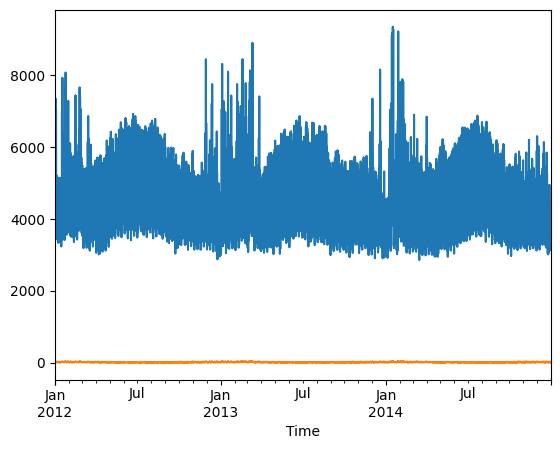

In [10]:
# create a line plot
from pandas import read_csv
from matplotlib import pyplot
datos["Demand"].plot()
datos["Temperature"].plot()
plt.show()

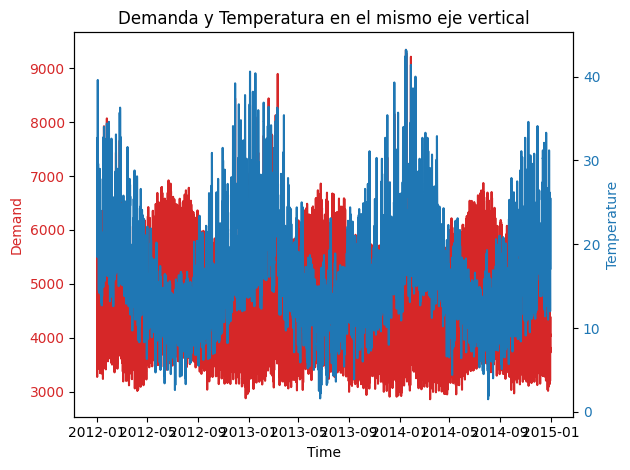

In [11]:
import matplotlib.pyplot as plt

# Crear el gráfico con dos ejes y
figura, ejes1 = plt.subplots()

# Graficar 'Demand' en el eje y principal
color = 'tab:red'
ejes1.set_title('Demanda y Temperatura en el mismo eje vertical')
ejes1.set_xlabel('Time')
ejes1.set_ylabel('Demand', color=color)
ejes1.plot(datos['Demand'], color=color)
ejes1.tick_params(axis='y', labelcolor=color)

# Crear un segundo eje y para 'Temperature'
ejes2 = ejes1.twinx()

color = 'tab:blue'
ejes2.set_ylabel('Temperature', color=color)
ejes2.plot(datos['Temperature'], color=color)
ejes2.tick_params(axis='y', labelcolor=color)

# Mostrar el gráfico
figura.tight_layout()
plt.show()

Para evitar que se superpongan:

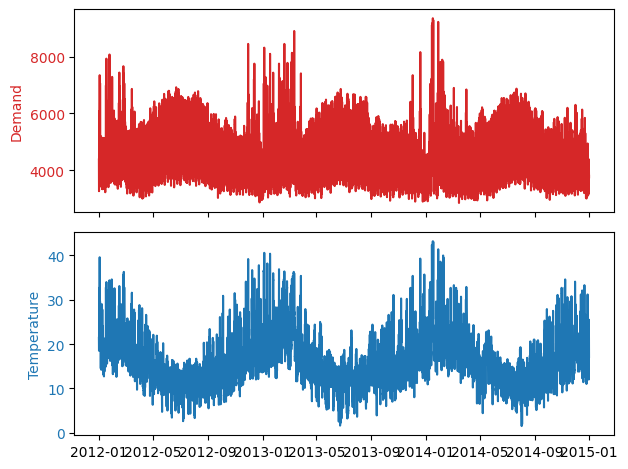

In [ ]:
# Crear la figura y dos subplots
figura, (ejes1, ejes2) = plt.subplots(nrows = 2, ncols = 1, sharex = True)

# Graficar 'Demand' en el eje inferior
ejes1.plot(datos['Demand'], color='tab:red')
ejes1.set_ylabel('Demand', color='tab:red')
ejes1.tick_params(axis='y', labelcolor='tab:red')

# Graficar 'Temperature' en el eje superior
ejes2.plot(datos['Temperature'], color='tab:blue')
ejes2.set_ylabel('Temperature', color='tab:blue')
ejes2.tick_params(axis='y', labelcolor='tab:blue')

# Ajustar el layout para evitar superposiciones
figura.tight_layout()

# Mostrar el gráfico
plt.show()

## Gráfico interactivo

In [12]:
import plotly.graph_objs as go

In [13]:
temperatura = go.Scatter(x=datos['Temperature'].index, y=datos['Temperature'].values, name = 'Temperature', line=dict(color='royalblue', width=0.7), yaxis='y')
demanda = go.Scatter(x=datos['Demand'].index, y=datos['Demand'].values, name = 'Demand', line=dict(color='red', width=0.7), yaxis='y2')


In [14]:
layout_temp = go.Layout(title='Temperatura y Demanda de energía eléctrica',
                xaxis=dict(title='Fecha'), # Eje de tiempo
                   yaxis  = dict(title='ºC', color='royalblue', overlaying='y2'), # Eje para temperatura
                   yaxis2 = dict(title='Energía', color='purple', side='right'))  # Eje para demanda

In [15]:
fig = go.Figure(data=[temperatura, demanda], layout=layout_temp)
fig.show()

Output hidden; open in https://colab.research.google.com to view.

## Visualización apilada

Veo que en mi serie de datos, sólo tengo unas pocas horas de datos del final de 2011

In [16]:
datos.index.min(), datos.index.max(), datos.index.freq

(Timestamp('2011-12-31 13:00:00'),
 Timestamp('2014-12-31 12:30:00'),
 <30 * Minutes>)

Modificamos datos para que el índice sean años completos. Para ello creo un DataFrame desde el inicio del primer año hasta el final del último

In [17]:

from datetime import datetime, timedelta
serie_anual= pd.Series(np.arange(datetime(2011,1,1,0,0),
                                 datetime(2014,12,31,23,30),
                                 timedelta(minutes=30)).astype(datetime))
datos_anual = pd.DataFrame(index = serie_anual)

y le concateno los datos.

In [18]:
datos_anual = pd.concat([datos_anual, datos])
datos_anual

,Demand,Temperature,Holiday
2011-01-01 00:00:00,NaN,NaN,NaN
2011-01-01 00:30:00,NaN,NaN,NaN
2011-01-01 01:00:00,NaN,NaN,NaN
2011-01-01 01:30:00,NaN,NaN,NaN
2011-01-01 02:00:00,NaN,NaN,NaN
...,...,...,...
2014-12-31 10:30:00,3873.448714,19.0,False
2014-12-31 11:00:00,3791.637322,18.5,False
2014-12-31 11:30:00,3724.835666,17.7,False
2014-12-31 12:00:00,3761.886854,17.3,False


In [19]:
from pandas import Grouper
grupos_anuales = datos.groupby(Grouper(freq="A"))

<ipython-input-19-b2349c3b1794>:2: FutureWarning:

'A' is deprecated and will be removed in a future version, please use 'YE' instead.



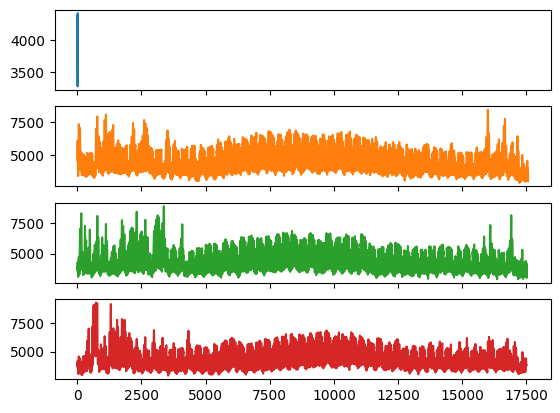

In [20]:
years = pd.DataFrame(index = np.arange(366*24*2))
for name, group in grupos_anuales:
    years[name.year] = group.reset_index()["Demand"]

years.plot(subplots=True, legend=False)
pyplot.show()

,2011,2012,2013,2014
Time,,,,
2011-12-31 21:30:00,22.55,NaN,NaN,NaN
2011-12-31 22:00:00,24.10,NaN,NaN,NaN
2011-12-31 22:30:00,25.20,NaN,NaN,NaN
2011-12-31 23:00:00,26.30,NaN,NaN,NaN
2011-12-31 23:30:00,27.70,NaN,NaN,NaN
